In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
pip install stable-baselines3 gymnasium numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.2 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# =========================================
# DISASTER DQN - COMPLETE IMPLEMENTATION
# =========================================
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"

import json
import copy
import numpy as np
import pandas as pd
import random
from collections import deque
from math import radians, sin, cos, sqrt, atan2, ceil

# Import torch BEFORE gymnasium to avoid circular import
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Now import gymnasium
import gymnasium as gym
from gymnasium import spaces

# -------------------------
# CONSTANTS
# -------------------------
MINUTES_PER_STEP = 15

STABILIZATION_TIME = {
    "critical": 1.0,
    "serious": 0.5,
    "moderate": 0.25
}

MORTALITY_RATES = {
    "critical": {
        "0-30min": 0.15,
        "30-60min": 0.25,
        "60+min": 0.40
    },
    "serious": {
        "0-60min": 0.02,
        "60-180min": 0.08,
        "180+min": 0.20
    },
    "moderate": {
        "0-120min": 0.005,
        "120-360min": 0.02,
        "360+min": 0.10
    }
}

def transport_survival_rate(distance_km, severity):
    if severity == "critical":
        return max(0.7, 0.98 - (distance_km / 10) * 0.02)
    elif severity == "serious":
        return max(0.85, 0.99 - (distance_km / 20) * 0.01)
    else:
        return max(0.95, 0.995 - (distance_km / 30) * 0.005)

def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return 6371.0 * c

def total_free_hospital_beds(hospitals):
    return sum(max(0, h["available_beds"]) for h in hospitals)

def total_free_shelter_space(shelters):
    return sum(max(0, s["capacity"] - s["occupied"]) for s in shelters)

def generate_severity_breakdown(injured_total):
    critical = int(injured_total * 0.20)
    serious = int(injured_total * 0.35)
    moderate = injured_total - critical - serious
    return {"critical": critical, "serious": serious, "moderate": moderate}

# =========================================
# ENVIRONMENT
# =========================================

class DisasterEnv(gym.Env):
    
    def __init__(self, all_zones, survival_mode=True):
        super().__init__()
        self.all_zones = all_zones
        self.survival_mode = survival_mode
        
        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(low=-1.0, high=1e6, shape=(34,), dtype=np.float32)
        
        self.zone = None
        self.clusters = []
        self.hospitals = []
        self.shelters = []
        self.cluster_idx = 0
        self.report = {}
        self.timestep = 0
        self.hospital_queue = []
        self.max_timesteps = 80

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.zone = copy.deepcopy(np.random.choice(self.all_zones))
        
        self.clusters = self.zone["people_clusters"]
        
        for c in self.clusters:
            if "severity" not in c:
                injured_total = c.get("injured_total", c.get("injured", 0))
                c["severity"] = generate_severity_breakdown(injured_total)
                c["severity_alive"] = copy.deepcopy(c["severity"])
                c["dead_by_severity"] = {"critical": 0, "serious": 0, "moderate": 0}
        
        self.hospitals = self.zone["hospitals"]
        self.shelters = self.zone["shelters"]
        
        tr = self.zone["transport_resources"]
        self.ambulances = tr["ambulances"]
        self.ambulance_capacity = tr["ambulance_capacity"]
        self.buses = tr["buses"]
        self.bus_capacity = tr["bus_capacity"]
        
        dr = self.zone["disaster_resources"]
        self.boats = dr.get("boats", 0)
        self.boat_capacity = dr.get("boat_capacity", 10)
        
        self.cluster_idx = 0
        self.timestep = 0
        self.hospital_queue = []
        self._reset_report()
        
        return self._get_obs(), {}

    def _reset_report(self):
        self.report = {
            "zone_id": self.zone["zone_id"],
            "disaster_type": self.zone["disaster_type"],
            "injured_saved": 0,
            "injured_saved_critical": 0,
            "injured_saved_serious": 0,
            "injured_saved_moderate": 0,
            "displaced_saved": 0,
            "injured_unsafe": 0,
            "displaced_unsafe": 0,
            "died_critical": 0,
            "died_serious": 0,
            "died_moderate": 0,
            "died_transport": 0,
            "total_distance_km": 0.0,
            "reward": 0.0,
            "penalty": 0.0,
            "ambulance_trips": 0,
            "bus_trips": 0,
            "boat_trips": 0,
            "beds_freed": 0,
            "beds_occupied_peak": 0
        }

    def _update_hospital_queue(self):
        if not self.hospital_queue:
            return
        
        new_queue = []
        for entry in self.hospital_queue:
            entry["time_remaining"] -= 1
            if entry["time_remaining"] <= 0:
                entry["hospital"]["available_beds"] += 1
                self.report["beds_freed"] += 1
            else:
                new_queue.append(entry)
        
        self.hospital_queue = new_queue

    def _apply_mortality(self):
        if not self.survival_mode:
            return
        
        minutes_elapsed = self.timestep * MINUTES_PER_STEP
        
        for c in self.clusters[self.cluster_idx:]:
            if c.get("rescued", 0) > 0:
                continue
            
            for severity in ["critical", "serious", "moderate"]:
                alive = c["severity_alive"].get(severity, 0)
                if alive <= 0:
                    continue
                
                if severity == "critical":
                    if minutes_elapsed <= 30:
                        rate = MORTALITY_RATES["critical"]["0-30min"]
                    elif minutes_elapsed <= 60:
                        rate = MORTALITY_RATES["critical"]["30-60min"]
                    else:
                        rate = MORTALITY_RATES["critical"]["60+min"]
                elif severity == "serious":
                    if minutes_elapsed <= 60:
                        rate = MORTALITY_RATES["serious"]["0-60min"]
                    elif minutes_elapsed <= 180:
                        rate = MORTALITY_RATES["serious"]["60-180min"]
                    else:
                        rate = MORTALITY_RATES["serious"]["180+min"]
                else:
                    if minutes_elapsed <= 120:
                        rate = MORTALITY_RATES["moderate"]["0-120min"]
                    elif minutes_elapsed <= 360:
                        rate = MORTALITY_RATES["moderate"]["120-360min"]
                    else:
                        rate = MORTALITY_RATES["moderate"]["360+min"]
                
                deaths = int(alive * rate)
                deaths = min(deaths, alive)
                
                c["severity_alive"][severity] -= deaths
                c["dead_by_severity"][severity] += deaths

    def _get_obs(self):
        if self.cluster_idx >= len(self.clusters):
            return np.zeros(34, dtype=np.float32)
        
        c = self.clusters[self.cluster_idx]
        cl_lat = c["location"]["lat"]
        cl_lon = c["location"]["lon"]
        
        critical = c["severity_alive"].get("critical", 0)
        serious = c["severity_alive"].get("serious", 0)
        moderate = c["severity_alive"].get("moderate", 0)
        total_injured_alive = critical + serious + moderate
        displaced = c["uninjured_displaced"]
        
        total_beds = total_free_hospital_beds(self.hospitals)
        available_hospitals = [h for h in self.hospitals if h["available_beds"] > 0]
        if available_hospitals:
            best_h = min(available_hospitals,
                         key=lambda x: haversine_distance(cl_lat, cl_lon,
                                                          x["location"]["lat"],
                                                          x["location"]["lon"]))
            h_dist = haversine_distance(cl_lat, cl_lon,
                                        best_h["location"]["lat"],
                                        best_h["location"]["lon"])
            h_stab_time = best_h.get("avg_stabilization_hours", 3)
        else:
            h_dist = 999.0
            h_stab_time = 3
        
        total_shelter = total_free_shelter_space(self.shelters)
        available_shelters = [s for s in self.shelters if s["capacity"] - s["occupied"] > 0]
        if available_shelters:
            best_s = min(available_shelters,
                         key=lambda x: haversine_distance(cl_lat, cl_lon,
                                                          x["location"]["lat"],
                                                          x["location"]["lon"]))
            s_dist = haversine_distance(cl_lat, cl_lon,
                                        best_s["location"]["lat"],
                                        best_s["location"]["lon"])
        else:
            s_dist = 999.0
        
        amb_trips = ceil(total_injured_alive / self.ambulance_capacity) if total_injured_alive > 0 else 0
        bus_trips = ceil(displaced / self.bus_capacity) if displaced > 0 else 0
        boat_trips = ceil(displaced / self.boat_capacity) if displaced > 0 else 0
        
        can_inj = 1.0 if (total_injured_alive > 0 and total_beds > 0 and self.ambulances > 0) else 0.0
        can_bus = 1.0 if (displaced > 0 and total_shelter > 0 and self.buses > 0) else 0.0
        can_boat = 1.0 if (displaced > 0 and total_shelter > 0 and self.boats > 0 and self.zone["disaster_type"] == "flood") else 0.0
        can_both = 1.0 if (can_inj and (can_bus or can_boat)) else 0.0
        
        minutes_elapsed = self.timestep * MINUTES_PER_STEP
        critical_urgency = min(minutes_elapsed / 60.0, 1.0) if critical > 0 else 0.0
        serious_urgency = min(minutes_elapsed / 180.0, 1.0) if serious > 0 else 0.0
        moderate_urgency = min(minutes_elapsed / 360.0, 1.0) if moderate > 0 else 0.0
        
        transport_risk_critical = 1.0 - transport_survival_rate(h_dist, "critical")
        transport_risk_serious = 1.0 - transport_survival_rate(h_dist, "serious")
        transport_risk_moderate = 1.0 - transport_survival_rate(h_dist, "moderate")
        
        return np.array([
            min(critical, 200), min(serious, 300), min(moderate, 500), min(displaced, 500),
            min(total_beds, 1000), min(total_shelter, 1000),
            min(h_dist, 200), min(s_dist, 200),
            min(self.ambulances, 100), min(self.buses, 100), min(self.boats, 100),
            self.ambulance_capacity, self.bus_capacity, self.boat_capacity,
            min(amb_trips, 50), min(bus_trips, 50), min(boat_trips, 50),
            self.zone["risk_score"],
            1.0 if self.zone["disaster_type"] == "flood" else 0.0,
            1.0 if self.zone["disaster_type"] == "wind" else 0.0,
            self.cluster_idx, len(self.clusters),
            can_inj, can_bus, can_boat, can_both,
            critical_urgency, serious_urgency, moderate_urgency,
            transport_risk_critical, transport_risk_serious, transport_risk_moderate,
            h_stab_time, min(len(self.hospital_queue), 50),
        ], dtype=np.float32)

    def _execute_injured_transport(self, cl_lat, cl_lon, severity_counts):
        if self.ambulances <= 0:
            return {}, 0, 0, {}
        
        total_beds = total_free_hospital_beds(self.hospitals)
        if total_beds <= 0:
            return {}, 0, 0, {}
        
        priority_order = ["critical", "serious", "moderate"]
        total_to_transport = sum(severity_counts.values())
        if total_to_transport == 0:
            return {}, 0, 0, {}
        
        trips_needed = ceil(total_to_transport / self.ambulance_capacity)
        parallel_amb = min(trips_needed, self.ambulances)
        num_rounds = ceil(trips_needed / parallel_amb) if parallel_amb > 0 else 0
        max_saveable = parallel_amb * self.ambulance_capacity * num_rounds
        max_saveable = min(max_saveable, total_beds)
        
        saved_by_severity = {}
        transport_deaths_by_severity = {}
        total_distance = 0.0
        remaining_capacity = max_saveable
        
        hospitals_by_distance = sorted(
            [h for h in self.hospitals if h["available_beds"] > 0],
            key=lambda h: haversine_distance(cl_lat, cl_lon, h["location"]["lat"], h["location"]["lon"])
        )
        
        if not hospitals_by_distance:
            return {}, 0, 0, {}
        
        for severity in priority_order:
            count = severity_counts.get(severity, 0)
            if count == 0 or remaining_capacity == 0:
                continue
            
            to_transport = min(count, remaining_capacity)
            transported_this_severity = 0
            died_this_severity = 0
            
            for hospital in hospitals_by_distance:
                if transported_this_severity >= to_transport:
                    break
                
                if hospital["available_beds"] <= 0:
                    continue
                
                space_in_hospital = hospital["available_beds"]
                remaining_to_place = to_transport - transported_this_severity
                allocate_here = min(space_in_hospital, remaining_to_place)
                
                dist = haversine_distance(cl_lat, cl_lon,
                                          hospital["location"]["lat"],
                                          hospital["location"]["lon"])
                
                survival_rate = transport_survival_rate(dist, severity)
                survived = int(allocate_here * survival_rate)
                died_in_transport = allocate_here - survived
                
                hospital["available_beds"] -= survived
                
                stab_hours = STABILIZATION_TIME[severity]
                stab_steps = int(stab_hours * 60 / MINUTES_PER_STEP)
                for _ in range(survived):
                    self.hospital_queue.append({
                        "hospital": hospital,
                        "severity": severity,
                        "time_remaining": max(1, stab_steps)
                    })
                
                trips_here = ceil(allocate_here / self.ambulance_capacity)
                total_distance += dist * trips_here
                
                transported_this_severity += survived
                died_this_severity += died_in_transport
            
            if transported_this_severity > 0:
                saved_by_severity[severity] = transported_this_severity
                transport_deaths_by_severity[severity] = died_this_severity
                remaining_capacity -= (transported_this_severity + died_this_severity)
        
        trips_used = ceil(sum(saved_by_severity.values()) / self.ambulance_capacity)
        
        occupied = sum(h["total_beds"] - h["available_beds"] for h in self.hospitals)
        self.report["beds_occupied_peak"] = max(self.report["beds_occupied_peak"], occupied)
        
        return saved_by_severity, total_distance, trips_used, transport_deaths_by_severity

    def _execute_displaced_bus(self, cl_lat, cl_lon, displaced):
        if displaced <= 0 or self.buses <= 0:
            return 0, 0, 0

        total_shelter = total_free_shelter_space(self.shelters)
        if total_shelter <= 0:
            return 0, 0, 0

        trips_needed = ceil(displaced / self.bus_capacity)
        parallel_buses = min(trips_needed, self.buses)
        num_rounds = ceil(trips_needed / parallel_buses) if parallel_buses > 0 else 0
        max_saveable = parallel_buses * self.bus_capacity * num_rounds
        actually_save = min(max_saveable, total_shelter, displaced)

        shelters_by_distance = sorted(
            [s for s in self.shelters if s["capacity"] - s["occupied"] > 0],
            key=lambda s: haversine_distance(cl_lat, cl_lon, s["location"]["lat"], s["location"]["lon"])
        )
        
        if not shelters_by_distance:
            return 0, 0, 0

        total_distance = 0.0
        placed = 0
        
        for shelter in shelters_by_distance:
            if placed >= actually_save:
                break
            
            space = shelter["capacity"] - shelter["occupied"]
            if space <= 0:
                continue
            
            allocate_here = min(space, actually_save - placed)
            shelter["occupied"] += allocate_here
            
            dist = haversine_distance(cl_lat, cl_lon,
                                      shelter["location"]["lat"],
                                      shelter["location"]["lon"])
            trips_here = ceil(allocate_here / self.bus_capacity)
            total_distance += dist * trips_here
            
            placed += allocate_here

        trips_used = ceil(placed / self.bus_capacity)
        return placed, total_distance, trips_used

    def _execute_displaced_boat(self, cl_lat, cl_lon, displaced):
        if displaced <= 0 or self.boats <= 0:
            return 0, 0, 0

        total_shelter = total_free_shelter_space(self.shelters)
        if total_shelter <= 0:
            return 0, 0, 0

        trips_needed = ceil(displaced / self.boat_capacity)
        parallel_boats = min(trips_needed, self.boats)
        num_rounds = ceil(trips_needed / parallel_boats) if parallel_boats > 0 else 0
        max_saveable = parallel_boats * self.boat_capacity * num_rounds
        actually_save = min(max_saveable, total_shelter, displaced)

        shelters_by_distance = sorted(
            [s for s in self.shelters if s["capacity"] - s["occupied"] > 0],
            key=lambda s: haversine_distance(cl_lat, cl_lon, s["location"]["lat"], s["location"]["lon"])
        )
        
        if not shelters_by_distance:
            return 0, 0, 0

        total_distance = 0.0
        placed = 0
        
        for shelter in shelters_by_distance:
            if placed >= actually_save:
                break
            
            space = shelter["capacity"] - shelter["occupied"]
            if space <= 0:
                continue
            
            allocate_here = min(space, actually_save - placed)
            shelter["occupied"] += allocate_here
            
            dist = haversine_distance(cl_lat, cl_lon,
                                      shelter["location"]["lat"],
                                      shelter["location"]["lon"])
            trips_here = ceil(allocate_here / self.boat_capacity)
            total_distance += dist * trips_here
            
            placed += allocate_here

        trips_used = ceil(placed / self.boat_capacity)
        return placed, total_distance, trips_used

    def step(self, action):
        if self.timestep >= self.max_timesteps:
            return self._get_obs(), 0.0, True, False, {}
        
        self._update_hospital_queue()
        self._apply_mortality()
        self.timestep += 1
        
        if self.cluster_idx >= len(self.clusters):
            self.cluster_idx = 0
            reward = 500
        else:
            reward = 0.0
        
        c = self.clusters[self.cluster_idx]
        cl_lat = c["location"]["lat"]
        cl_lon = c["location"]["lon"]
        
        critical = c["severity_alive"].get("critical", 0)
        serious = c["severity_alive"].get("serious", 0)
        moderate = c["severity_alive"].get("moderate", 0)
        total_injured_alive = critical + serious + moderate
        displaced = c["uninjured_displaced"]
        
        severity_counts = {"critical": critical, "serious": serious, "moderate": moderate}
        
        if total_injured_alive == 0 and displaced == 0:
            self.cluster_idx += 1
            return self._get_obs(), reward, False, False, {}
        
        penalty = 0.0
        risk = 1.0 + self.zone["risk_score"]
        minutes_elapsed = self.timestep * MINUTES_PER_STEP
        time_pressure = 1.0 + (minutes_elapsed / 60.0)
        
        has_injured = total_injured_alive > 0
        has_displaced = displaced > 0
        
        # ACTION 0: NOOP
        if action == 0:
            penalty += 2000 * critical * risk * time_pressure
            penalty += 1000 * serious * risk * time_pressure
            penalty += 500 * moderate * risk * time_pressure
            penalty += 300 * displaced * risk
            self.report["injured_unsafe"] += total_injured_alive
            self.report["displaced_unsafe"] += displaced
        
        # ACTION 1: Injured Only
        elif action == 1:
            if has_injured:
                saved_by_sev, dist, trips, transport_deaths = self._execute_injured_transport(
                    cl_lat, cl_lon, severity_counts
                )
                
                if saved_by_sev:
                    for sev, count in saved_by_sev.items():
                        if sev == "critical":
                            time_bonus = max(0, 500 - minutes_elapsed * 10)
                            reward += 450 * count + time_bonus - 0.05 * dist
                            self.report["injured_saved_critical"] += count
                        elif sev == "serious":
                            time_bonus = max(0, 300 - minutes_elapsed * 5)
                            reward += 280 * count + time_bonus - 0.05 * dist
                            self.report["injured_saved_serious"] += count
                        else:
                            reward += 180 * count - 0.05 * dist
                            self.report["injured_saved_moderate"] += count
                        
                        c["severity_alive"][sev] -= count
                        c["rescued"] = c.get("rescued", 0) + count
                    
                    self.report["injured_saved"] += sum(saved_by_sev.values())
                    self.report["total_distance_km"] += dist
                    self.report["ambulance_trips"] += trips
                    
                    for sev, deaths in transport_deaths.items():
                        if deaths > 0:
                            self.report["died_transport"] += deaths
                            penalty += deaths * 500 * risk
                    
                    for sev in ["critical", "serious", "moderate"]:
                        unsaved = severity_counts[sev] - saved_by_sev.get(sev, 0) - transport_deaths.get(sev, 0)
                        if unsaved > 0:
                            mult = 2000 if sev == "critical" else 1000 if sev == "serious" else 500
                            penalty += mult * unsaved * risk * time_pressure
                            self.report["injured_unsafe"] += unsaved
                else:
                    penalty += 2000 * critical * risk * time_pressure
                    penalty += 1000 * serious * risk * time_pressure
                    penalty += 500 * moderate * risk * time_pressure
                    self.report["injured_unsafe"] += total_injured_alive
            
            if has_displaced:
                penalty += 300 * displaced * risk
                self.report["displaced_unsafe"] += displaced
        
        # ACTION 2: Displaced (Bus)
        elif action == 2:
            if has_displaced:
                actual_saved, dist, trips = self._execute_displaced_bus(cl_lat, cl_lon, displaced)
                if actual_saved > 0:
                    reward += 140 * actual_saved - 0.05 * dist
                    self.report["displaced_saved"] += actual_saved
                    self.report["total_distance_km"] += dist
                    self.report["bus_trips"] += trips
                    c["uninjured_displaced"] -= actual_saved
                    unsaved = displaced - actual_saved
                    if unsaved > 0:
                        penalty += 300 * unsaved * risk
                        self.report["displaced_unsafe"] += unsaved
                else:
                    penalty += 300 * displaced * risk
                    self.report["displaced_unsafe"] += displaced
            
            if has_injured:
                penalty += 2000 * critical * risk * time_pressure
                penalty += 1000 * serious * risk * time_pressure
                penalty += 500 * moderate * risk * time_pressure
                self.report["injured_unsafe"] += total_injured_alive
        
        # ACTION 3: Displaced (Boat)
        elif action == 3:
            is_flood = self.zone["disaster_type"] == "flood"
            total_displaced_saved = 0
            if has_displaced and is_flood:
                actual_saved, dist, trips = self._execute_displaced_boat(cl_lat, cl_lon, displaced)
                if actual_saved > 0:
                    reward += 160 * actual_saved - 0.05 * dist
                    self.report["displaced_saved"] += actual_saved
                    self.report["total_distance_km"] += dist
                    self.report["boat_trips"] += trips
                    total_displaced_saved += actual_saved
                    unsaved = displaced - actual_saved
                    if unsaved > 0:
                        actual_saved2, dist2, trips2 = self._execute_displaced_bus(cl_lat, cl_lon, unsaved)
                        if actual_saved2 > 0:
                            reward += 140 * actual_saved2 - 0.05 * dist2
                            self.report["displaced_saved"] += actual_saved2
                            self.report["total_distance_km"] += dist2
                            self.report["bus_trips"] += trips2
                            total_displaced_saved += actual_saved2
                            still_unsaved = unsaved - actual_saved2
                            if still_unsaved > 0:
                                penalty += 300 * still_unsaved * risk
                                self.report["displaced_unsafe"] += still_unsaved
                        else:
                            penalty += 300 * unsaved * risk
                            self.report["displaced_unsafe"] += unsaved
                else:
                    actual_saved2, dist2, trips2 = self._execute_displaced_bus(cl_lat, cl_lon, displaced)
                    if actual_saved2 > 0:
                        reward += 140 * actual_saved2 - 0.05 * dist2
                        self.report["displaced_saved"] += actual_saved2
                        self.report["total_distance_km"] += dist2
                        self.report["bus_trips"] += trips2
                        total_displaced_saved += actual_saved2
                        still_unsaved = displaced - actual_saved2
                        if still_unsaved > 0:
                            penalty += 300 * still_unsaved * risk
                            self.report["displaced_unsafe"] += still_unsaved
                    else:
                        penalty += 300 * displaced * risk
                        self.report["displaced_unsafe"] += displaced
                c["uninjured_displaced"] -= total_displaced_saved
            elif has_displaced:
                actual_saved, dist, trips = self._execute_displaced_bus(cl_lat, cl_lon, displaced)
                if actual_saved > 0:
                    reward += 80 * actual_saved - 0.05 * dist
                    self.report["displaced_saved"] += actual_saved
                    self.report["total_distance_km"] += dist
                    self.report["bus_trips"] += trips
                    c["uninjured_displaced"] -= actual_saved
                    unsaved = displaced - actual_saved
                    if unsaved > 0:
                        penalty += 300 * unsaved * risk
                        self.report["displaced_unsafe"] += unsaved
                else:
                    penalty += 300 * displaced * risk
                    self.report["displaced_unsafe"] += displaced
            
            if has_injured:
                penalty += 2000 * critical * risk * time_pressure
                penalty += 1000 * serious * risk * time_pressure
                penalty += 500 * moderate * risk * time_pressure
                self.report["injured_unsafe"] += total_injured_alive
        
        # ACTION 4: BOTH
        elif action == 4:
            injured_saved_flag = False
            
            if has_injured:
                saved_by_sev, dist, trips, transport_deaths = self._execute_injured_transport(
                    cl_lat, cl_lon, severity_counts
                )
                
                if saved_by_sev:
                    for sev, count in saved_by_sev.items():
                        if sev == "critical":
                            time_bonus = max(0, 500 - minutes_elapsed * 10)
                            reward += 450 * count + time_bonus - 0.05 * dist
                            self.report["injured_saved_critical"] += count
                        elif sev == "serious":
                            time_bonus = max(0, 300 - minutes_elapsed * 5)
                            reward += 280 * count + time_bonus - 0.05 * dist
                            self.report["injured_saved_serious"] += count
                        else:
                            reward += 180 * count - 0.05 * dist
                            self.report["injured_saved_moderate"] += count
                        
                        c["severity_alive"][sev] -= count
                        c["rescued"] = c.get("rescued", 0) + count
                    
                    self.report["injured_saved"] += sum(saved_by_sev.values())
                    self.report["total_distance_km"] += dist
                    self.report["ambulance_trips"] += trips
                    
                    for sev, deaths in transport_deaths.items():
                        if deaths > 0:
                            self.report["died_transport"] += deaths
                            penalty += deaths * 500 * risk
                    
                    total_saved = sum(saved_by_sev.values())
                    total_died = sum(transport_deaths.values())
                    injured_saved_flag = (total_saved + total_died >= total_injured_alive)
                    
                    if not injured_saved_flag:
                        for sev in ["critical", "serious", "moderate"]:
                            unsaved = severity_counts[sev] - saved_by_sev.get(sev, 0) - transport_deaths.get(sev, 0)
                            if unsaved > 0:
                                mult = 2000 if sev == "critical" else 1000 if sev == "serious" else 500
                                penalty += mult * unsaved * risk * time_pressure
                                self.report["injured_unsafe"] += unsaved
                else:
                    penalty += 2000 * critical * risk * time_pressure
                    penalty += 1000 * serious * risk * time_pressure
                    penalty += 500 * moderate * risk * time_pressure
                    self.report["injured_unsafe"] += total_injured_alive
            else:
                injured_saved_flag = True
            
            displaced_saved_flag = False
            if has_displaced:
                actual_dis_saved = 0
                remaining_dis = displaced
                
                if self.zone["disaster_type"] == "flood" and self.boats > 0:
                    boat_saved, dist, trips = self._execute_displaced_boat(cl_lat, cl_lon, remaining_dis)
                    if boat_saved > 0:
                        reward += 160 * boat_saved - 0.05 * dist
                        self.report["displaced_saved"] += boat_saved
                        self.report["total_distance_km"] += dist
                        self.report["boat_trips"] += trips
                        actual_dis_saved += boat_saved
                        remaining_dis -= boat_saved
                
                if remaining_dis > 0:
                    bus_saved, dist, trips = self._execute_displaced_bus(cl_lat, cl_lon, remaining_dis)
                    if bus_saved > 0:
                        reward += 140 * bus_saved - 0.05 * dist
                        self.report["displaced_saved"] += bus_saved
                        self.report["total_distance_km"] += dist
                        self.report["bus_trips"] += trips
                        actual_dis_saved += bus_saved
                        remaining_dis -= bus_saved
                
                c["uninjured_displaced"] -= actual_dis_saved
                
                if remaining_dis > 0:
                    penalty += 300 * remaining_dis * risk
                    self.report["displaced_unsafe"] += remaining_dis
                
                displaced_saved_flag = (remaining_dis == 0)
            else:
                displaced_saved_flag = True
            
            if injured_saved_flag and displaced_saved_flag and (has_injured or has_displaced):
                speed_bonus = max(0, 1000 - minutes_elapsed * 20)
                reward += 1500 * risk + speed_bonus
        
        self.report["reward"] += reward
        self.report["penalty"] += penalty
        
        self.cluster_idx += 1
        done = self.timestep >= self.max_timesteps
        
        if done and self.survival_mode:
            for c in self.clusters:
                for sev in ["critical", "serious", "moderate"]:
                    deaths = c["dead_by_severity"].get(sev, 0)
                    if sev == "critical":
                        self.report["died_critical"] += deaths
                    elif sev == "serious":
                        self.report["died_serious"] += deaths
                    else:
                        self.report["died_moderate"] += deaths
        
        net_reward = reward - penalty
        return self._get_obs(), net_reward, done, False, {}


# =========================================
# DQN NETWORK
# =========================================

class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, action_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)


# =========================================
# REPLAY BUFFER
# =========================================

class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return np.array(state), action, reward, np.array(next_state), done
    
    def __len__(self):
        return len(self.buffer)


# =========================================
# DQN AGENT
# =========================================

class DQNAgent:
    def __init__(self, state_dim, action_dim, lr=5e-5, gamma=0.995):
        self.action_dim = action_dim
        self.gamma = gamma
        
        self.policy_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer()
        
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.999
        
        self.update_counter = 0
        self.target_update_freq = 500
    
    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            q_values = self.policy_net(state_tensor)
            return q_values.argmax().item()
    
    def update(self, batch_size=64):
        if len(self.memory) < batch_size:
            return 0.0
        
        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)
        
        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones)
        
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1))
        
        next_q = self.target_net(next_states).max(1)[0].detach()
        target_q = rewards + (1 - dones) * self.gamma * next_q
        
        loss = F.mse_loss(current_q.squeeze(), target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        self.update_counter += 1
        if self.update_counter % self.target_update_freq == 0:
            self.update_target_network()
        
        return loss.item()
    
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())
    
    def save(self, path):
        torch.save({
            'policy_net': self.policy_net.state_dict(),
            'target_net': self.target_net.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'epsilon': self.epsilon
        }, path)
    
    def load(self, path):
        checkpoint = torch.load(path)
        self.policy_net.load_state_dict(checkpoint['policy_net'])
        self.target_net.load_state_dict(checkpoint['target_net'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        self.epsilon = checkpoint['epsilon']


# =========================================
# TRAINING
# =========================================

with open("/kaggle/working/resource_database_dqn_85.json") as f:
    data = json.load(f)

ZONES = list(data["zones"].values())

print(f"✅ Loaded {len(ZONES)} zones")

env = DisasterEnv(ZONES, survival_mode=True)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(state_dim, action_dim, lr=5e-5, gamma=0.995)

print("\n🚀 Training DQN...")
print(f"   State dim: {state_dim}, Action dim: {action_dim}")
print(f"   Epsilon: {agent.epsilon:.2f} → {agent.epsilon_min}")
print(f"   Warmup: 500 episodes (fill replay buffer)")

num_episodes = 3000  
batch_size = 64
best_save_rate = 0.0
warmup_episodes = 500

# ── Tracking containers ──────────────────────────────────────────────────────
episode_rewards = []   # raw episode reward each episode
save_rates      = []   # eval save-rate recorded every 100 episodes
losses          = []   # loss value every update step (after warmup)
epsilons        = []   # epsilon value at end of each episode
# ─────────────────────────────────────────────────────────────────────────────

for episode in range(num_episodes):
    state, _ = env.reset()
    episode_reward = 0
    done = False
    
    while not done:
        action = agent.select_action(state, training=True)
        next_state, reward, done, _, _ = env.step(action)
        
        # Normalize reward to prevent instability
        reward = np.clip(reward / 10000.0, -1.0, 1.0)
        
        agent.memory.push(state, action, reward, next_state, done)
        
        # Only update after warmup
        if episode >= warmup_episodes:
            loss = agent.update(batch_size)
            if loss is not None and loss != 0.0:          # ← store every update loss
                losses.append(loss)
        
        episode_reward += reward
        state = next_state
    
    # ── Per-episode tracking ──────────────────────────────────────────────────
    episode_rewards.append(episode_reward)
    epsilons.append(agent.epsilon)
    # ─────────────────────────────────────────────────────────────────────────

    # Evaluate every 100 episodes
    if (episode + 1) % 100 == 0:
        # Quick evaluation
        total_saved = 0
        total_people = 0
        
        for _ in range(len(ZONES)):
            eval_state, _ = env.reset()
            eval_done = False
            
            while not eval_done:
                eval_action = agent.select_action(eval_state, training=False)
                eval_state, _, eval_done, _, _ = env.step(eval_action)
            
            total_injured_original = sum(c["severity"]["critical"] + c["severity"]["serious"] + c["severity"]["moderate"] for c in env.clusters)
            total_displaced_original = sum(c.get("uninjured_displaced", 0) for c in env.zone["people_clusters"])
            
            injured_still_alive = sum(c["severity_alive"]["critical"] + c["severity_alive"]["serious"] + c["severity_alive"]["moderate"] for c in env.clusters)
            displaced_still_unsafe = sum(c["uninjured_displaced"] for c in env.clusters)
            
            total_dead = sum(c["dead_by_severity"]["critical"] + c["dead_by_severity"]["serious"] + c["dead_by_severity"]["moderate"] for c in env.clusters)
            
            actual_injured_saved = total_injured_original - injured_still_alive - total_dead
            actual_displaced_saved = total_displaced_original - displaced_still_unsafe
            
            total_saved += actual_injured_saved + actual_displaced_saved
            total_people += total_injured_original + total_displaced_original
        
        save_rate = (total_saved / total_people * 100) if total_people > 0 else 0.0

        # ── Per-eval tracking ─────────────────────────────────────────────────
        save_rates.append(save_rate)
        # ─────────────────────────────────────────────────────────────────────
        
        print(f"[Episode {episode+1:4d}] Reward: {episode_reward:8.0f} | "
              f"Epsilon: {agent.epsilon:.3f} | Save Rate: {save_rate:.1f}%")
        
        if save_rate > best_save_rate:
            best_save_rate = save_rate
            agent.save("/kaggle/working/disaster_dqn_best.pth")
            print(f"  ✅ New best! Saved model.")

print("\n✅ Training complete!")

# Load best model
agent.load("/kaggle/working/disaster_dqn_best.pth")

# =========================================
# FINAL EVALUATION
# =========================================

print("\n📊 Final evaluation...")

eval_env = DisasterEnv(ZONES, survival_mode=True)
zone_rows = []

for z in ZONES:
    eval_env.zone = copy.deepcopy(z)
    eval_env.clusters = eval_env.zone["people_clusters"]
    
    for c in eval_env.clusters:
        if "severity" not in c:
            injured_total = c.get("injured_total", c.get("injured", 0))
            c["severity"] = generate_severity_breakdown(injured_total)
            c["severity_alive"] = copy.deepcopy(c["severity"])
            c["dead_by_severity"] = {"critical": 0, "serious": 0, "moderate": 0}
    
    eval_env.hospitals = eval_env.zone["hospitals"]
    eval_env.shelters = eval_env.zone["shelters"]
    
    tr = eval_env.zone["transport_resources"]
    eval_env.ambulances = tr["ambulances"]
    eval_env.ambulance_capacity = tr["ambulance_capacity"]
    eval_env.buses = tr["buses"]
    eval_env.bus_capacity = tr["bus_capacity"]
    
    dr = eval_env.zone["disaster_resources"]
    eval_env.boats = dr.get("boats", 0)
    eval_env.boat_capacity = dr.get("boat_capacity", 10)
    
    eval_env.cluster_idx = 0
    eval_env.timestep = 0
    eval_env.hospital_queue = []
    eval_env._reset_report()
    
    obs, _ = eval_env.reset()
    done = False
    
    while not done:
        action = agent.select_action(obs, training=False)
        obs, _, done, _, _ = eval_env.step(action)
    
    total_injured_original = sum(c["severity"]["critical"] + c["severity"]["serious"] + c["severity"]["moderate"] for c in eval_env.clusters)
    injured_still_alive = sum(c["severity_alive"]["critical"] + c["severity_alive"]["serious"] + c["severity_alive"]["moderate"] for c in eval_env.clusters)
    displaced_still_unsafe = sum(c["uninjured_displaced"] for c in eval_env.clusters)
    
    actual_injured_saved = total_injured_original - injured_still_alive - eval_env.report["died_critical"] - eval_env.report["died_serious"] - eval_env.report["died_moderate"] - eval_env.report["died_transport"]
    actual_displaced_saved = sum(c.get("uninjured_displaced", 0) for c in z["people_clusters"]) - displaced_still_unsafe
    
    total_people = total_injured_original + sum(c["uninjured_displaced"] for c in z["people_clusters"])
    total_saved = actual_injured_saved + actual_displaced_saved
    total_dead = eval_env.report["died_critical"] + eval_env.report["died_serious"] + eval_env.report["died_moderate"] + eval_env.report["died_transport"]
    
    eval_env.report["total_injured"] = total_injured_original
    eval_env.report["total_displaced"] = sum(c["uninjured_displaced"] for c in z["people_clusters"])
    eval_env.report["total_people"] = total_people
    eval_env.report["injured_saved"] = actual_injured_saved
    eval_env.report["displaced_saved"] = actual_displaced_saved
    eval_env.report["total_saved"] = total_saved
    eval_env.report["total_dead"] = total_dead
    eval_env.report["overall_save_%"] = (total_saved / total_people * 100) if total_people > 0 else 0
    eval_env.report["injured_save_%"] = (actual_injured_saved / total_injured_original * 100) if total_injured_original > 0 else 0
    eval_env.report["displaced_save_%"] = (actual_displaced_saved / eval_env.report["total_displaced"] * 100) if eval_env.report["total_displaced"] > 0 else 0
    eval_env.report["mortality_%"] = (total_dead / total_injured_original * 100) if total_injured_original > 0 else 0
    
    zone_rows.append(eval_env.report)

zone_df = pd.DataFrame(zone_rows)

print("\n" + "="*120)
print("DQN RESULTS WITH PROPER DISTANCE ALLOCATION & BED TURNOVER")
print("="*120)
cols = ["zone_id", "disaster_type", "total_people", "total_saved", "overall_save_%",
        "injured_saved", "displaced_saved", "beds_freed", "beds_occupied_peak"]
print(zone_df[cols].to_string(index=False))

print("\n" + "="*120)
print("OVERALL STATISTICS")
print("="*120)
total_inj = zone_df["total_injured"].sum()
total_dis = zone_df["total_displaced"].sum()
total_ppl = zone_df["total_people"].sum()
saved_inj = zone_df["injured_saved"].sum()
saved_dis = zone_df["displaced_saved"].sum()
saved_all = saved_inj + saved_dis
total_dead = zone_df["total_dead"].sum()

print(f"Total injured saved  : {saved_inj:,} / {total_inj:,} ({saved_inj/total_inj*100:.1f}%)")
print(f"Total displaced saved: {saved_dis:,} / {total_dis:,} ({saved_dis/total_dis*100:.1f}%)")
print(f"OVERALL SAVE RATE    : {saved_all:,} / {total_ppl:,} ({saved_all/total_ppl*100:.1f}%)")
print(f"Total deaths         : {total_dead:,}")
print(f"Beds freed (turnover): {zone_df['beds_freed'].sum():,}")
print(f"Peak bed occupancy   : {zone_df['beds_occupied_peak'].sum():,}")

# Save
torch.save(agent.policy_net.state_dict(), "/kaggle/working/disaster_dqn_final.pth")
zone_df.to_csv("/kaggle/working/zone_summary_dqn.csv", index=False)

# =========================================
# SAVE TRAINING CURVES TO CSV
# =========================================

# Episode-level metrics
training_df = pd.DataFrame({
    "episode": list(range(1, num_episodes + 1)),
    "episode_reward": episode_rewards,
    "epsilon": epsilons,
})
training_df.to_csv("/kaggle/working/training_curves.csv", index=False)

# Eval save-rates (every 100 episodes)
eval_episodes = list(range(100, num_episodes + 1, 100))
eval_df = pd.DataFrame({
    "episode": eval_episodes[:len(save_rates)],
    "save_rate_%": save_rates,
})
eval_df.to_csv("/kaggle/working/eval_save_rates.csv", index=False)

# Loss values (one per update step after warmup)
loss_df = pd.DataFrame({
    "update_step": list(range(1, len(losses) + 1)),
    "loss": losses,
})
loss_df.to_csv("/kaggle/working/training_losses.csv", index=False)

print("\n💾 Files saved:")
print("  - disaster_dqn_best.pth (checkpoint)")
print("  - disaster_dqn_final.pth (final policy)")
print("  - zone_summary_dqn.csv")
print("  - training_curves.csv    (episode reward + epsilon per episode)")
print("  - eval_save_rates.csv    (save rate every 100 episodes)")
print("  - training_losses.csv    (loss per update step)")

print("\n✅ DQN COMPLETE!")
print(f"Achieved: {saved_all/total_ppl*100:.1f}%")


✅ Loaded 8 zones

🚀 Training DQN...
   State dim: 34, Action dim: 5
   Epsilon: 1.00 → 0.05
   Warmup: 500 episodes (fill replay buffer)

[Episode  100] Reward:      -78 | Epsilon: 1.000 | Save Rate: 36.2%
  ✅ New best! Saved model.
[Episode  200] Reward:      -73 | Epsilon: 1.000 | Save Rate: 36.0%
[Episode  300] Reward:      -76 | Epsilon: 1.000 | Save Rate: 36.7%
  ✅ New best! Saved model.
[Episode  400] Reward:      -78 | Epsilon: 1.000 | Save Rate: 34.0%
[Episode  500] Reward:      -76 | Epsilon: 1.000 | Save Rate: 36.8%
  ✅ New best! Saved model.
[Episode  600] Reward:      -78 | Epsilon: 0.050 | Save Rate: 75.0%
  ✅ New best! Saved model.
[Episode  700] Reward:      -76 | Epsilon: 0.050 | Save Rate: 76.5%
  ✅ New best! Saved model.
[Episode  800] Reward:      -76 | Epsilon: 0.050 | Save Rate: 74.9%
[Episode  900] Reward:      -73 | Epsilon: 0.050 | Save Rate: 72.2%
[Episode 1000] Reward:      -76 | Epsilon: 0.050 | Save Rate: 77.7%
  ✅ New best! Saved model.
[Episode 1100] Rewa

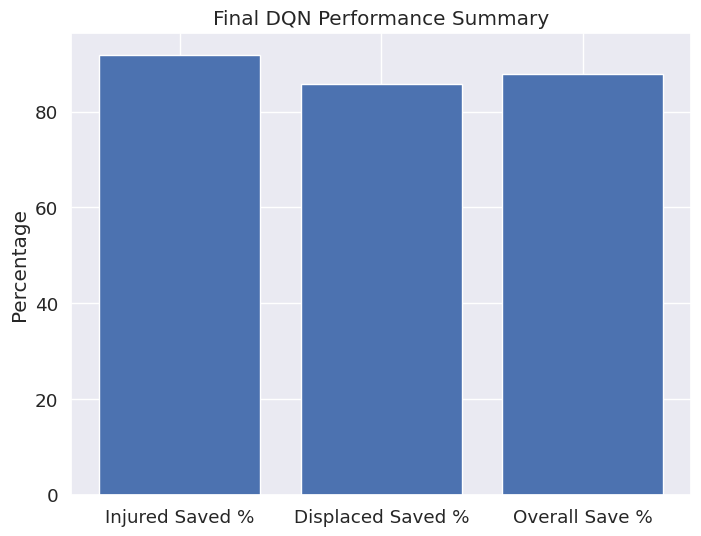

In [ ]:
metrics = [
    saved_inj/total_inj*100,
    saved_dis/total_dis*100,
    saved_all/total_ppl*100
]

labels = ["Injured Saved %", "Displaced Saved %", "Overall Save %"]

plt.figure(figsize=(8,6))
plt.bar(labels, metrics)
plt.title("Final DQN Performance Summary")
plt.ylabel("Percentage")
plt.show()

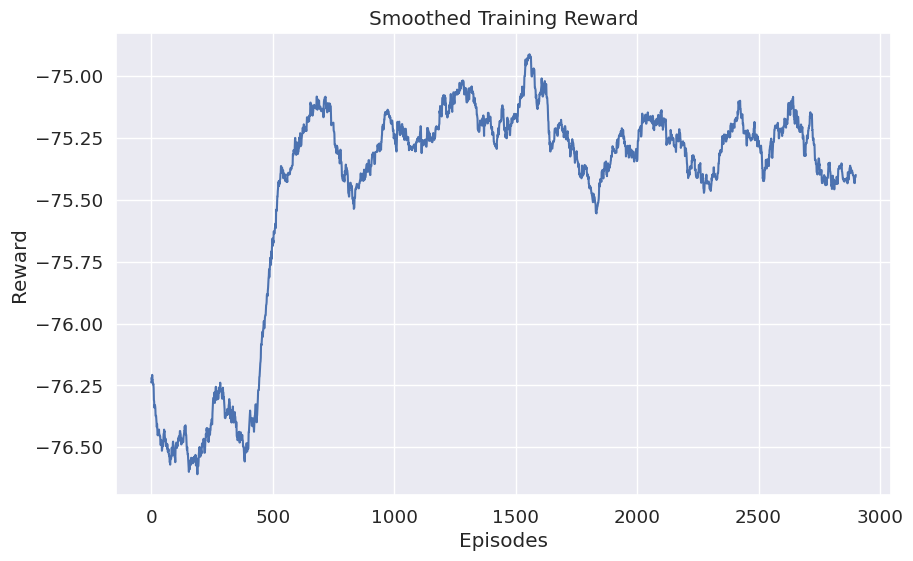

In [ ]:
window = 100
smooth = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,6))
plt.plot(smooth)
plt.title("Smoothed Training Reward")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.grid(True)
plt.show()